# 15. Hyperparameter Tuning, Model Comparison, and Pipelines

Once a predictive workflow exists, the next engineering question is not "can I fit a model?" but rather "how do I compare models and tune them without fooling myself?" Hyperparameter tuning is where many practical machine-learning workflows quietly go wrong. Teams try many configurations, choose the one that looks best, and then accidentally report an optimistic performance estimate because the search procedure itself has already adapted to the validation data.

This notebook treats tuning as part of a disciplined decision workflow. We will keep a final test window untouched, use expanding temporal validation folds inside the earlier data, tune several model families under a common pipeline interface, and then compare tuned and default models honestly. The setting remains operational and tabular: a seller-day support panel where the target is daily SLA breach risk.

The notebook also emphasizes a very practical message. Hyperparameter tuning is not a ritual in which more search always produces a better model. Sometimes tuning matters a lot. Sometimes it confirms that a simple baseline was already close to optimal. What matters is not the drama of the search; what matters is whether the comparison is reproducible, leakage-aware, and defensible.

## Learning Objectives

By the end of this notebook, you should be able to:

1. distinguish learned model parameters from hyperparameters chosen outside the fitting objective,
2. explain why tuning, model comparison, and preprocessing must all be nested inside an honest validation design,
3. implement expanding-window temporal validation for panel-style operational data,
4. tune multiple model families using a shared pipeline interface,
5. compare defaults against tuned configurations, and
6. interpret when a simpler model is preferable even after a broader search.

## 1. Core Mathematical Ideas

Let $m \in \mathcal{M}$ denote a model family, such as logistic regression, random forest, or gradient boosting. Within a given family, the training algorithm learns parameters $\theta$ after we specify a hyperparameter vector $\lambda$.

For fixed $(m, \lambda)$, the fitted parameters solve a training problem of the form

$$
\hat{\theta}_{m,\lambda} = \arg\min_{\theta} \; \mathcal{L}_{\text{train}}\bigl(\theta; m, \lambda\bigr).
$$

The hyperparameters are **not** learned by this optimization. They are chosen by an outer procedure that evaluates candidate configurations on held-out validation data. If we use $K$ validation folds and a scoring rule $S$, the tuning problem can be written as

$$
\hat{\lambda}_m = \arg\max_{\lambda \in \Lambda_m} \; \frac{1}{K} \sum_{k=1}^{K} S\Bigl(f\bigl(x; \hat{\theta}^{(k)}_{m,\lambda}\bigr), \mathcal{D}^{(k)}_{\text{val}}\Bigr).
$$

After choosing the best hyperparameters within each family, we compare the resulting tuned models and select a final family

$$
\hat{m} = \arg\max_{m \in \mathcal{M}} \; \widehat{S}_{\text{CV}}(m, \hat{\lambda}_m).
$$

Only after that selection should we look at the final untouched test set.

A second idea matters just as much as the optimization itself: **preprocessing is part of the model**. If a workflow standardizes variables, imputes missing values, or learns category mappings, those steps also estimate quantities from the data. A pipeline therefore represents a composed predictor

$$
\hat{y} = h_{\hat{\theta}}\bigl(\psi_{\hat{\eta}}(x)\bigr),
$$

where $\psi_{\hat{\eta}}$ is the preprocessing map with learned preprocessing quantities $\hat{\eta}$, and $h_{\hat{\theta}}$ is the predictive model. The preprocessing must be fit **inside each training fold**, not once on the full dataset, otherwise the validation score is contaminated.

This is why pipelines matter operationally. They ensure that the exact sequence of imputation, scaling, encoding, model fitting, and prediction is treated as one reproducible object (Pedregosa et al., 2012). In temporal settings, they must also be paired with a chronology-respecting validation scheme, because random splitting can distort the true deployment problem (Lai et al., 2024).

In [1]:
# Section focus: 1. Core Mathematical Ideas.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

from scipy.special import expit

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 220)
pd.options.display.float_format = '{:,.3f}'.format

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

rng = np.random.default_rng(2026)

## 2. Operational Setting and Feature Representation

We will reuse the same seller-day support-risk problem from the previous notebook, but with a slightly smaller panel so that repeated hyperparameter searches remain fast enough to support interactive teaching. The target is still `sla_breach_today`, and the predictor set is an engineered operational representation built from lagged levels, rolling summaries, normalized rates, and cyclical calendar terms.

This is a good environment for a tuning lecture because it has three useful properties:

1. the data are temporal, so validation design matters,
2. the features mix numeric scales and categorical segments, so pipelines matter,
3. the signal is strong enough to compare model families, but not so strong that every search looks identical.

In [2]:
# Section focus: 2. Operational Setting and Feature Representation.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def simulate_support_operations(n_sellers=180, n_days=150, random_state=2026):
    """Create a simulated support operations data set for the 15. Hyperparameter Tuning, Model Comparison, and Pipelines case study.
    
    Parameters
    ----------
    n_sellers : object
        Count or size setting for the support operations calculation.
    n_days : object
        Count or size setting for the support operations calculation.
    random_state : object
        Random seed or generator control used to make results reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(random_state)
    seller_ids = np.arange(n_sellers)

    tiers = np.array(['enterprise', 'growth', 'mid_market', 'long_tail'])
    tier = rng.choice(tiers, size=n_sellers, p=[0.18, 0.27, 0.30, 0.25])

    regions = np.array(['NA', 'EU', 'APAC', 'LATAM'])
    region = rng.choice(regions, size=n_sellers, p=[0.32, 0.24, 0.28, 0.16])

    scale = rng.normal(0, 1, n_sellers)
    automation = rng.normal(0, 1, n_sellers)
    complexity = rng.normal(0, 1, n_sellers)
    seller_effect = rng.normal(0, 0.35, n_sellers)

    tier_scale = {'enterprise': 0.90, 'growth': 0.45, 'mid_market': 0.05, 'long_tail': -0.35}
    staffing_bonus = {'enterprise': 1.5, 'growth': 0.8, 'mid_market': 0.3, 'long_tail': -0.2}
    region_friction = {'NA': -0.08, 'EU': 0.04, 'APAC': 0.12, 'LATAM': 0.18}

    backlog_prev = np.clip(rng.normal(6.5, 1.8, n_sellers), 1, None)
    backlog_prev2 = backlog_prev - rng.normal(0.3, 0.5, n_sellers)
    breach_prev = rng.binomial(1, 0.10, n_sellers)
    incident_prev = rng.poisson(0.5, n_sellers)

    rows = []

    for day in range(n_days):
        dow = day % 7
        weekday_load = [0.15, 0.22, 0.18, 0.10, 0.06, -0.14, -0.20][dow]
        promo_cycle = 0.7 * np.sin(2 * np.pi * day / 28)
        incident_cycle = 0.6 * np.cos(2 * np.pi * day / 18)

        for i in seller_ids:
            log_orders = 2.65 + tier_scale[tier[i]] + 0.32 * scale[i] + 0.08 * promo_cycle + rng.normal(0, 0.14)
            orders = int(np.clip(rng.poisson(np.exp(log_orders)), 8, 220))

            promo_spend = max(0.0, 35 + 12 * (tier[i] in ['enterprise', 'growth']) + 14 * max(scale[i], 0) + 12 * promo_cycle + rng.normal(0, 8))
            kb_views = max(5.0, 25 + 8 * automation[i] + 0.45 * orders + rng.normal(0, 6))

            incidents = rng.poisson(
                max(0.05, 0.25 + 0.35 * max(complexity[i], -0.8) + 0.18 * max(incident_cycle, -0.8) + 0.015 * backlog_prev[i] + 0.12 * incident_prev[i])
            )

            tickets_mean = max(
                0.6,
                1.2 + 0.055 * orders + 1.1 * max(complexity[i], -1.2) - 0.55 * automation[i] + 0.75 * incidents + 0.35 * seller_effect[i] + weekday_load,
            )
            tickets = int(rng.poisson(tickets_mean))

            agent_hours = max(1.0, 3.8 + 0.028 * orders + staffing_bonus[tier[i]] - 0.35 * automation[i] + rng.normal(0, 0.9))
            backlog = max(0.2, 0.60 * backlog_prev[i] + 0.72 * tickets - 0.62 * agent_hours + 0.85 * incidents + rng.normal(0, 0.8))

            backlog_pressure = backlog / max(agent_hours, 1)
            ticket_rate = tickets / max(orders, 1)
            self_service_gap = tickets / max(kb_views, 1)
            backlog_growth = max(backlog_prev[i] - backlog_prev2[i], 0)
            incident_trend = max(incidents - incident_prev[i], 0)

            resolution_minutes = max(
                10.0,
                26 + 9.5 * backlog_pressure + 52 * ticket_rate + 8 * incidents + 12 * region_friction[region[i]] - 5 * automation[i] + 4.5 * backlog_growth + rng.normal(0, 5),
            )

            breach_logit = (
                -3.05
                + 0.42 * np.log1p(backlog)
                + 3.9 * ticket_rate
                + 1.4 * self_service_gap
                + 0.16 * incidents
                + 0.95 * breach_prev[i]
                + 0.36 * backlog_growth
                + 0.26 * incident_trend
                + 0.45 * region_friction[region[i]]
                + 0.10 * (dow in [0, 1, 2])
                - 0.20 * automation[i]
            )
            breach = rng.binomial(1, expit(breach_logit))

            rows.append(
                {
                    'seller_id': i,
                    'date': pd.Timestamp('2024-01-01') + pd.Timedelta(days=day),
                    'tier': tier[i],
                    'region': region[i],
                    'automation_score': automation[i],
                    'complexity_score': complexity[i],
                    'day_of_week': dow,
                    'orders_today': orders,
                    'tickets_today': tickets,
                    'promo_spend_today': promo_spend,
                    'knowledge_base_views_today': kb_views,
                    'incident_count_today': incidents,
                    'agent_hours_today': agent_hours,
                    'backlog_end_today': backlog,
                    'resolution_minutes_today': resolution_minutes,
                    'sla_breach_today': breach,
                }
            )

            backlog_prev2[i] = backlog_prev[i]
            backlog_prev[i] = backlog
            breach_prev[i] = breach
            incident_prev[i] = incidents

    return pd.DataFrame(rows)


def build_feature_matrix(df):
    """Build the feature matrix object used in the 15. Hyperparameter Tuning, Model Comparison, and Pipelines analysis.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the feature matrix workflow for later analysis.
    """
    df = df.sort_values(['seller_id', 'date']).copy()

    lag_cols = [
        'orders_today', 'tickets_today', 'promo_spend_today', 'knowledge_base_views_today',
        'incident_count_today', 'agent_hours_today', 'backlog_end_today',
        'resolution_minutes_today', 'sla_breach_today'
    ]
    for col in lag_cols:
        df[f'{col}_lag1'] = df.groupby('seller_id')[col].shift(1)

    df['tickets_3d_avg'] = df.groupby('seller_id')['tickets_today'].transform(lambda s: s.shift(1).rolling(3, min_periods=2).mean())
    df['tickets_7d_avg'] = df.groupby('seller_id')['tickets_today'].transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())
    df['backlog_3d_avg'] = df.groupby('seller_id')['backlog_end_today'].transform(lambda s: s.shift(1).rolling(3, min_periods=2).mean())
    df['backlog_7d_avg'] = df.groupby('seller_id')['backlog_end_today'].transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())
    df['breach_14d_rate'] = df.groupby('seller_id')['sla_breach_today'].transform(lambda s: s.shift(1).rolling(14, min_periods=4).mean())
    df['incident_7d_sum'] = df.groupby('seller_id')['incident_count_today'].transform(lambda s: s.shift(1).rolling(7, min_periods=3).sum())

    df['log_orders_lag1'] = np.log1p(df['orders_today_lag1'])
    df['log_backlog_lag1'] = np.log1p(df['backlog_end_today_lag1'])
    df['backlog_per_hour_lag1'] = df['backlog_end_today_lag1'] / df['agent_hours_today_lag1'].clip(lower=1)
    df['ticket_rate_lag1'] = df['tickets_today_lag1'] / df['orders_today_lag1'].clip(lower=1)
    df['self_service_gap_lag1'] = df['tickets_today_lag1'] / df['knowledge_base_views_today_lag1'].clip(lower=1)
    df['backlog_growth_vs_7d'] = df['backlog_end_today_lag1'] - df['backlog_7d_avg']
    df['promo_pressure_interaction'] = df['promo_spend_today_lag1'] * df['ticket_rate_lag1']
    df['incident_pressure_interaction'] = df['incident_count_today_lag1'] * df['backlog_per_hour_lag1']
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    return df.dropna().reset_index(drop=True)


ops = simulate_support_operations()
feature_df = build_feature_matrix(ops)

feature_overview = pd.DataFrame([
    {'quantity': 'Rows after lag/rolling construction', 'value': len(feature_df)},
    {'quantity': 'Unique sellers', 'value': feature_df['seller_id'].nunique()},
    {'quantity': 'Unique dates', 'value': feature_df['date'].nunique()},
    {'quantity': 'Overall breach rate', 'value': round(feature_df['sla_breach_today'].mean(), 3)},
    {'quantity': 'Median yesterday backlog', 'value': round(feature_df['backlog_end_today_lag1'].median(), 2)},
    {'quantity': 'Median 14-day breach rate', 'value': round(feature_df['breach_14d_rate'].median(), 3)},
])

display(feature_overview)
feature_df[['date', 'tier', 'region', 'tickets_today_lag1', 'backlog_end_today_lag1', 'ticket_rate_lag1', 'breach_14d_rate', 'sla_breach_today']].head()

,quantity,value
0,Rows after lag/rolling construction,"26,280.000"
1,Unique sellers,180.000
2,Unique dates,146.000
3,Overall breach rate,0.241
4,Median yesterday backlog,0.200
5,Median 14-day breach rate,0.214


,date,tier,region,tickets_today_lag1,backlog_end_today_lag1,ticket_rate_lag1,breach_14d_rate,sla_breach_today
0,2024-01-05,enterprise,APAC,2.000,0.200,0.065,0.000,0
1,2024-01-06,enterprise,APAC,3.000,0.200,0.075,0.000,0
2,2024-01-07,enterprise,APAC,2.000,0.200,0.029,0.000,0
3,2024-01-08,enterprise,APAC,4.000,0.200,0.111,0.000,0
4,2024-01-09,enterprise,APAC,2.000,0.200,0.032,0.000,0


The feature matrix is already engineered before any tuning begins. That is deliberate. This notebook is not about inventing new features; it is about comparing model families **holding the representation fixed**.

That separation is healthy in practice. Otherwise, changes in the search process and changes in the feature space become entangled, and it becomes difficult to say what actually improved the workflow.

## 3. Honest Temporal Splits for Tuning and Final Assessment

We will use a three-stage chronology-aware workflow:

1. **Final test window**: the most recent 15 percent of dates, never touched during tuning,
2. **Tuning window**: the earlier dates used for search and model comparison,
3. **Expanding-window CV inside the tuning window**: each fold trains on the past and validates on a later block.

This gives us a clean separation between model selection and final assessment. It also reflects a realistic deployment question: how well would a configuration chosen on earlier operational history perform on later unseen periods?

,stage,rows,start,end
0,Tuning window,22500,2024-01-05,2024-05-08
1,Final test window,3780,2024-05-09,2024-05-29


,fold,train_start,train_end,validation_start,validation_end,train_rows,validation_rows
0,1,2024-01-05,2024-03-21,2024-03-22,2024-04-06,13860,2880
1,2,2024-01-05,2024-04-06,2024-04-07,2024-04-22,16740,2880
2,3,2024-01-05,2024-04-22,2024-04-23,2024-05-08,19620,2880


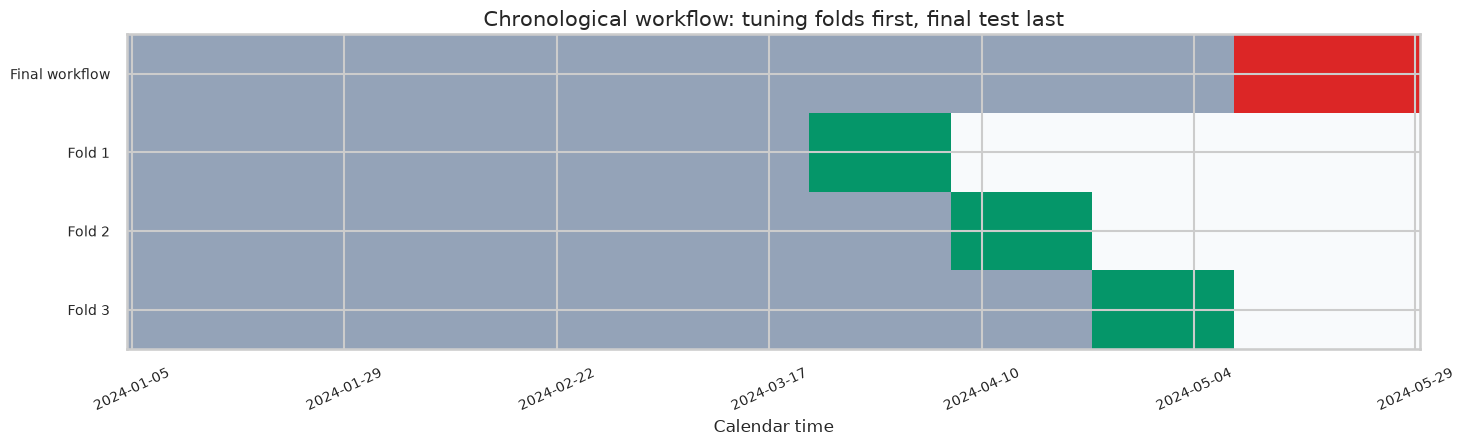

In [3]:
# Section focus: 3. Honest Temporal Splits for Tuning and Final Assessment.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def split_tuning_and_test(df, test_fraction=0.15):
    """Carry out the split tuning and test step used in the 15. Hyperparameter Tuning, Model Comparison, and Pipelines workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    test_fraction : object
        Test split or held-out value used by this workflow.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    unique_dates = np.array(sorted(df['date'].unique()))
    n_test_days = max(1, int(len(unique_dates) * test_fraction))
    tuning_dates = set(unique_dates[:-n_test_days])
    test_dates = set(unique_dates[-n_test_days:])

    tuning_df = df[df['date'].isin(tuning_dates)].sort_values(['date', 'seller_id']).reset_index(drop=True)
    test_df = df[df['date'].isin(test_dates)].sort_values(['date', 'seller_id']).reset_index(drop=True)
    return tuning_df, test_df, unique_dates, unique_dates[:-n_test_days], unique_dates[-n_test_days:]


def make_expanding_date_splits(df, n_splits=3, val_days=16):
    """Construct the expanding date splits helper used in the 15. Hyperparameter Tuning, Model Comparison, and Pipelines workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    n_splits : object
        Count or size setting for the expanding date splits calculation.
    val_days : object
        The val days setting that controls the expanding date splits calculation in this notebook.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    unique_dates = np.array(sorted(df['date'].unique()))
    training_prefix = len(unique_dates) - n_splits * val_days
    split_starts = [training_prefix + i * val_days for i in range(n_splits)]

    splits = []
    summary_rows = []

    for fold, start in enumerate(split_starts, start=1):
        train_dates = set(unique_dates[:start])
        val_dates = set(unique_dates[start:start + val_days])

        train_idx = np.flatnonzero(df['date'].isin(train_dates).to_numpy())
        val_idx = np.flatnonzero(df['date'].isin(val_dates).to_numpy())
        splits.append((train_idx, val_idx))

        summary_rows.append(
            {
                'fold': fold,
                'train_start': unique_dates[0].date(),
                'train_end': unique_dates[start - 1].date(),
                'validation_start': unique_dates[start].date(),
                'validation_end': unique_dates[min(start + val_days - 1, len(unique_dates) - 1)].date(),
                'train_rows': len(train_idx),
                'validation_rows': len(val_idx),
            }
        )

    return splits, pd.DataFrame(summary_rows)


def make_timeline_matrix(all_dates, tuning_dates, test_dates, fold_summary):
    """Construct the timeline matrix helper used in the 15. Hyperparameter Tuning, Model Comparison, and Pipelines workflow.
    
    Parameters
    ----------
    all_dates : object
        Time index or time-span setting used by the simulated panel or monitoring window.
    tuning_dates : object
        Time index or time-span setting used by the simulated panel or monitoring window.
    test_dates : object
        Test split or held-out value used by this workflow.
    fold_summary : object
        The fold summary setting that controls the timeline matrix calculation in this notebook.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rows = []
    labels = ['Final workflow']
    
    base = np.zeros(len(all_dates), dtype=int)
    base[np.isin(all_dates, tuning_dates)] = 1
    base[np.isin(all_dates, test_dates)] = 3
    rows.append(base)

    for _, row in fold_summary.iterrows():
        fold_row = np.zeros(len(all_dates), dtype=int)
        train_mask = (all_dates >= pd.Timestamp(row['train_start'])) & (all_dates <= pd.Timestamp(row['train_end']))
        val_mask = (all_dates >= pd.Timestamp(row['validation_start'])) & (all_dates <= pd.Timestamp(row['validation_end']))
        fold_row[train_mask] = 1
        fold_row[val_mask] = 2
        rows.append(fold_row)
        labels.append(f'Fold {int(row["fold"])}')

    return np.vstack(rows), labels


tuning_df, test_df, all_dates, tuning_dates, test_dates = split_tuning_and_test(feature_df, test_fraction=0.15)
cv_splits, fold_summary = make_expanding_date_splits(tuning_df, n_splits=3, val_days=16)

split_overview = pd.DataFrame([
    {'stage': 'Tuning window', 'rows': len(tuning_df), 'start': tuning_df['date'].min().date(), 'end': tuning_df['date'].max().date()},
    {'stage': 'Final test window', 'rows': len(test_df), 'start': test_df['date'].min().date(), 'end': test_df['date'].max().date()},
])

display(split_overview)
display(fold_summary)

timeline_matrix, timeline_labels = make_timeline_matrix(all_dates, tuning_dates, test_dates, fold_summary)

cmap = ListedColormap(['#f8fafc', '#94a3b8', '#059669', '#dc2626'])

plt.figure(figsize=(15, 4.8))
plt.imshow(timeline_matrix, aspect='auto', cmap=cmap, interpolation='nearest')
plt.yticks(range(len(timeline_labels)), timeline_labels)
plt.xticks(
    ticks=np.linspace(0, len(all_dates) - 1, 7, dtype=int),
    labels=[pd.Timestamp(all_dates[i]).strftime('%Y-%m-%d') for i in np.linspace(0, len(all_dates) - 1, 7, dtype=int)],
    rotation=25,
)
plt.title('Chronological workflow: tuning folds first, final test last')
plt.xlabel('Calendar time')
plt.tight_layout()
plt.show()

The timeline plot is the picture to keep in mind while reading everything that follows. The final red segment is untouched during tuning. Each green validation block occurs strictly after its corresponding training block. No fold is allowed to "learn from the future."

Use the Honest Temporal Splits for Tuning and Final Assessment output to decide what the analysis should do next. The useful reading is the one that points to a follow-up action.


## 4. Pipelines and Search Spaces

We compare three families:

1. **Logistic regression (L2)**: a strong, interpretable linear baseline,
2. **Random forest**: a bagged tree model that can absorb nonlinearities and interactions,
3. **Histogram gradient boosting**: a boosted tree model with shrinkage and structural regularization.

All three models use the **same feature set** and the **same preprocessing pipeline**:

- median imputation for numeric features,
- standardization for numeric features,
- most-frequent imputation plus one-hot encoding for categorical features.

For tree models, scaling is not strictly necessary, but using one pipeline template across model families makes the comparison cleaner and easier to reproduce. More importantly, it guarantees that every learned preprocessing step stays inside the search object.

### Search budgets

| Model family | Search method | Hyperparameters explored |
|---|---|---|
| Logistic regression | Grid search | Regularization strength `C` |
| Random forest | Randomized search | `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features` |
| HistGradientBoosting | Randomized search | `learning_rate`, `max_depth`, `max_leaf_nodes`, `min_samples_leaf`, `l2_regularization` |

This mix is deliberate. Grid search is fine when the search space is very small. Randomized search is often more attractive once the space is wider and mixed-type, because it lets us cover more combinations with a fixed computational budget (Claesen et al., 2014; Pfisterer et al., 2018).

In [4]:
# Section focus: Search budgets.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

feature_cols = [
    'tier', 'region', 'automation_score', 'complexity_score', 'day_of_week',
    'orders_today_lag1', 'tickets_today_lag1', 'promo_spend_today_lag1',
    'knowledge_base_views_today_lag1', 'incident_count_today_lag1',
    'agent_hours_today_lag1', 'backlog_end_today_lag1', 'resolution_minutes_today_lag1',
    'log_orders_lag1', 'log_backlog_lag1', 'backlog_per_hour_lag1',
    'ticket_rate_lag1', 'self_service_gap_lag1', 'tickets_3d_avg', 'tickets_7d_avg',
    'backlog_3d_avg', 'backlog_7d_avg', 'breach_14d_rate', 'incident_7d_sum',
    'backlog_growth_vs_7d', 'promo_pressure_interaction', 'incident_pressure_interaction',
    'dow_sin', 'dow_cos'
]

categorical_cols = ['tier', 'region']
numeric_cols = [col for col in feature_cols if col not in categorical_cols]


def make_preprocessor():
    """Construct the preprocessor helper used in the 15. Hyperparameter Tuning, Model Comparison, and Pipelines workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the preprocessor workflow.
    """
    return ColumnTransformer(
        transformers=[
            (
                'numeric',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler()),
                ]),
                numeric_cols,
            ),
            (
                'categorical',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                ]),
                categorical_cols,
            ),
        ]
    )


def make_search_objects(cv_splits):
    """Construct the search objects helper used in the 15. Hyperparameter Tuning, Model Comparison, and Pipelines workflow.
    
    Parameters
    ----------
    cv_splits : object
        The cv splits setting that controls the search objects calculation in this notebook.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the search objects workflow.
    """
    searches = {}

    logistic_pipe = Pipeline([
        ('preprocessor', make_preprocessor()),
        ('model', LogisticRegression(max_iter=1500)),
    ])
    searches['Logistic regression (L2)'] = GridSearchCV(
        estimator=logistic_pipe,
        param_grid={'model__C': np.logspace(-2, 1, 7)},
        cv=cv_splits,
        scoring='roc_auc',
        refit=True,
        n_jobs=-1,
    )

    rf_pipe = Pipeline([
        ('preprocessor', make_preprocessor()),
        ('model', RandomForestClassifier(random_state=2026, n_jobs=1)),
    ])
    searches['Random forest'] = RandomizedSearchCV(
        estimator=rf_pipe,
        param_distributions={
            'model__n_estimators': [200, 300],
            'model__max_depth': [4, 6, 8, None],
            'model__min_samples_leaf': [1, 3, 5, 10],
            'model__max_features': ['sqrt', 0.5, None],
        },
        n_iter=10,
        cv=cv_splits,
        scoring='roc_auc',
        refit=True,
        random_state=2026,
        n_jobs=-1,
    )

    hgb_pipe = Pipeline([
        ('preprocessor', make_preprocessor()),
        ('model', HistGradientBoostingClassifier(random_state=2026)),
    ])
    searches['HistGradientBoosting'] = RandomizedSearchCV(
        estimator=hgb_pipe,
        param_distributions={
            'model__learning_rate': [0.03, 0.05, 0.10, 0.20],
            'model__max_depth': [3, 5, None],
            'model__max_leaf_nodes': [15, 31, 63],
            'model__min_samples_leaf': [20, 50, 100],
            'model__l2_regularization': [0.0, 0.1, 1.0],
        },
        n_iter=10,
        cv=cv_splits,
        scoring='roc_auc',
        refit=True,
        random_state=2026,
        n_jobs=-1,
    )

    return searches


def evaluate_probabilities(y_true, probs):
    """Evaluate probabilities for the 15. Hyperparameter Tuning, Model Comparison, and Pipelines decision workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    probs : object
        Predicted probabilities used by the decision rule.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    return {
        'test_auc': roc_auc_score(y_true, probs),
        'test_average_precision': average_precision_score(y_true, probs),
        'test_brier': brier_score_loss(y_true, probs),
        'test_log_loss': log_loss(y_true, probs),
    }


def tune_models(tuning_df, test_df, feature_cols, cv_splits):
    """Carry out the tune models step used in the 15. Hyperparameter Tuning, Model Comparison, and Pipelines workflow.
    
    Parameters
    ----------
    tuning_df : object
        Tabular data object used as the input or output of this workflow step.
    test_df : object
        Test split or held-out value used by this workflow.
    feature_cols : object
        Column or variable name used to select information from the input table.
    cv_splits : object
        The cv splits setting that controls the tune models calculation in this notebook.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    searches = make_search_objects(cv_splits)
    rows = []

    for model_name, search in searches.items():
        start = time.time()
        search.fit(tuning_df[feature_cols], tuning_df['sla_breach_today'])
        elapsed = time.time() - start

        probs = search.best_estimator_.predict_proba(test_df[feature_cols])[:, 1]
        metrics = evaluate_probabilities(test_df['sla_breach_today'], probs)

        rows.append(
            {
                'model_family': model_name,
                'search_method': 'Grid search' if isinstance(search, GridSearchCV) else 'Randomized search',
                'candidate_configs': len(search.cv_results_['params']),
                'best_cv_auc': search.best_score_,
                'fit_time_sec': elapsed,
                **metrics,
            }
        )

    return searches, pd.DataFrame(rows)


searches, tuned_results = tune_models(tuning_df, test_df, feature_cols, cv_splits)
tuned_results = tuned_results.sort_values('test_auc', ascending=False).reset_index(drop=True).round(3)
tuned_results

,model_family,search_method,candidate_configs,best_cv_auc,fit_time_sec,test_auc,test_average_precision,test_brier,test_log_loss
0,Logistic regression (L2),Grid search,7,0.761,1.937,0.768,0.548,0.148,0.463
1,HistGradientBoosting,Randomized search,10,0.757,2.474,0.765,0.546,0.149,0.465
2,Random forest,Randomized search,10,0.756,62.973,0.763,0.543,0.150,0.466


The tuned comparison is already informative. Because all three families were trained under the same chronology-aware workflow, differences are easier to trust.

A particularly good teaching outcome here is that the most complicated family still has to earn its place. In many operational problems, a tuned linear model remains competitive because the feature engineering has already encoded much of the relevant structure. Tuning then becomes a test of whether extra model flexibility truly buys out-of-sample value.

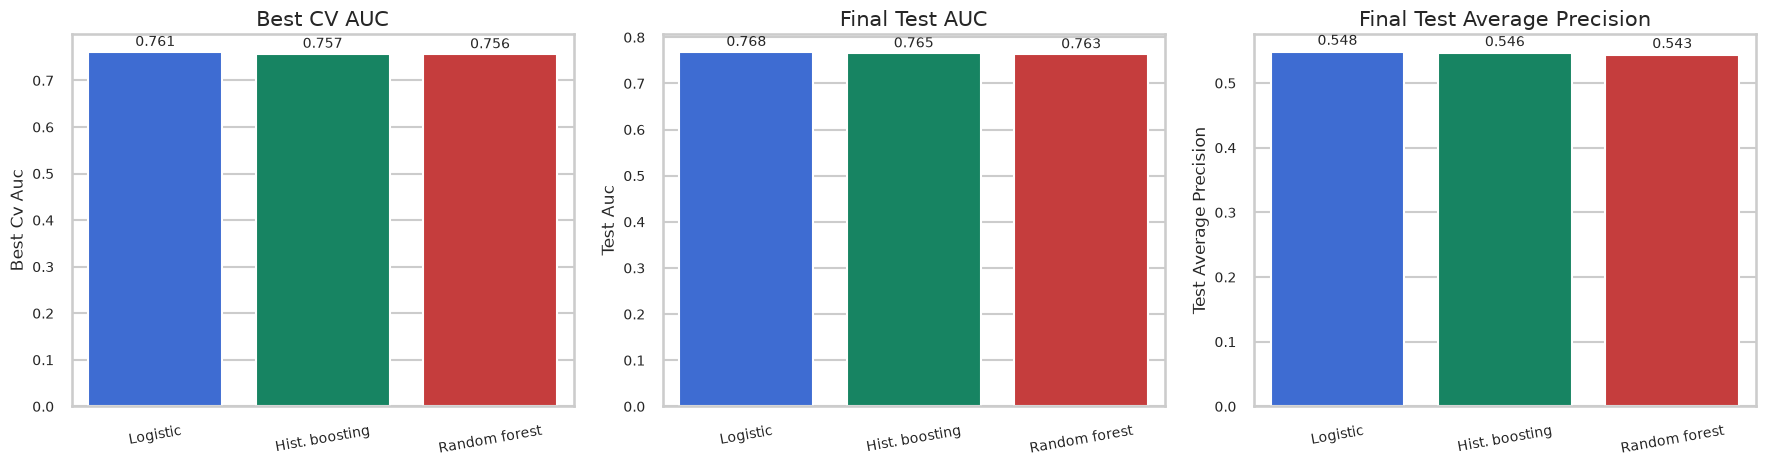

In [5]:
# Section focus: Search budgets.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

plot_results = tuned_results.copy()
plot_results['plot_model'] = plot_results['model_family'].replace({
    'Logistic regression (L2)': 'Logistic',
    'Random forest': 'Random forest',
    'HistGradientBoosting': 'Hist. boosting',
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metric_specs = [
    ('best_cv_auc', 'Best CV AUC', False),
    ('test_auc', 'Final Test AUC', False),
    ('test_average_precision', 'Final Test Average Precision', False),
]
palette = ['#2563eb', '#059669', '#dc2626']

for ax, (metric, title, lower_is_better) in zip(axes, metric_specs):
    ordered = plot_results.sort_values(metric, ascending=lower_is_better)
    sns.barplot(data=ordered, x='plot_model', y=metric, ax=ax, palette=palette)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=10, labelsize=10)

    for patch, value in zip(ax.patches, ordered[metric]):
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        ax.text(x, y + 0.006, f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

These plots separate three ideas that are often blurred together:

- **CV AUC** tells us how the search judged configurations during tuning,
- **test AUC** tells us how the selected configuration generalized to later unseen periods,
- **test average precision** emphasizes performance on the positive class, which matters when the operational target is a breach event.

If a family looks strong in CV but drops substantially on the final test window, that is a warning sign. If it stays strong, the workflow is behaving more credibly.

In [6]:
# Section focus: Search budgets.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def summarize_top_configs(search, model_name):
    """Summarize top configs for the 15. Hyperparameter Tuning, Model Comparison, and Pipelines analysis.
    
    Parameters
    ----------
    search : object
        The search setting that controls the top configs calculation in this notebook.
    model_name : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Intermediate result produced by the top configs calculation and reused by later cells.
    """
    results = pd.DataFrame(search.cv_results_).sort_values('mean_test_score', ascending=False).copy()

    if model_name == 'Logistic regression (L2)':
        cols = ['param_model__C', 'mean_test_score', 'std_test_score', 'rank_test_score']
    elif model_name == 'Random forest':
        cols = ['param_model__n_estimators', 'param_model__max_depth', 'param_model__min_samples_leaf', 'param_model__max_features', 'mean_test_score', 'std_test_score', 'rank_test_score']
    else:
        cols = ['param_model__learning_rate', 'param_model__max_depth', 'param_model__max_leaf_nodes', 'param_model__min_samples_leaf', 'param_model__l2_regularization', 'mean_test_score', 'std_test_score', 'rank_test_score']

    out = results[cols].head(5).reset_index(drop=True)
    return out.round(4)


for model_name in searches:
    print() 
    print(f'Top configurations for {model_name}')
    display(summarize_top_configs(searches[model_name], model_name))


Top configurations for Logistic regression (L2)


,param_model__C,mean_test_score,std_test_score,rank_test_score
0,0.032,0.761,0.010,1
1,0.010,0.761,0.011,2
2,0.100,0.761,0.010,3
3,0.316,0.761,0.010,4
4,3.162,0.761,0.010,5



Top configurations for Random forest


,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,param_model__max_features,mean_test_score,std_test_score,rank_test_score
0,200,6,5,None,0.756,0.011,1
1,200,8,10,None,0.755,0.010,2
2,300,4,5,None,0.754,0.012,3
3,200,4,3,None,0.754,0.012,4
4,200,4,1,0.500,0.754,0.013,5



Top configurations for HistGradientBoosting


,param_model__learning_rate,param_model__max_depth,param_model__max_leaf_nodes,param_model__min_samples_leaf,param_model__l2_regularization,mean_test_score,std_test_score,rank_test_score
0,0.030,None,15,20,1.000,0.757,0.011,1
1,0.030,5,31,50,0.100,0.757,0.009,2
2,0.030,3,63,50,0.000,0.757,0.011,3
3,0.030,3,63,100,1.000,0.757,0.012,4
4,0.050,5,31,50,0.000,0.756,0.010,5


The top-configuration tables are useful for two reasons.

First, they show that tuning usually identifies a **region** of good configurations rather than a magical single point. Second, they reveal how flat or sharp the search landscape is. If many neighboring configurations perform similarly, the workflow may be robust to modest retuning. If the winner is isolated and unstable, then the selected configuration should be treated with more caution.

In [7]:
# Section focus: Search budgets.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def evaluate_default_and_tuned_models(tuning_df, test_df, feature_cols, searches):
    """Evaluate default and tuned models for the 15. Hyperparameter Tuning, Model Comparison, and Pipelines decision workflow.
    
    Parameters
    ----------
    tuning_df : object
        Tabular data object used as the input or output of this workflow step.
    test_df : object
        Test split or held-out value used by this workflow.
    feature_cols : object
        Column or variable name used to select information from the input table.
    searches : object
        The searches setting that controls the default and tuned models calculation in this notebook.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    default_specs = {
        'Logistic': Pipeline([
            ('preprocessor', make_preprocessor()),
            ('model', LogisticRegression(max_iter=1500)),
        ]),
        'Random forest': Pipeline([
            ('preprocessor', make_preprocessor()),
            ('model', RandomForestClassifier(random_state=2026, n_jobs=1)),
        ]),
        'HistGradientBoosting': Pipeline([
            ('preprocessor', make_preprocessor()),
            ('model', HistGradientBoostingClassifier(random_state=2026)),
        ]),
    }

    rows = []
    for family, default_pipe in default_specs.items():
        default_pipe.fit(tuning_df[feature_cols], tuning_df['sla_breach_today'])
        default_probs = default_pipe.predict_proba(test_df[feature_cols])[:, 1]
        rows.append({'family': family, 'setting': 'Default', **evaluate_probabilities(test_df['sla_breach_today'], default_probs)})

        if family == 'Logistic':
            tuned_name = 'Logistic regression (L2)'
        else:
            tuned_name = family

        tuned_pipe = searches[tuned_name].best_estimator_
        tuned_probs = tuned_pipe.predict_proba(test_df[feature_cols])[:, 1]
        rows.append({'family': family, 'setting': 'Tuned', **evaluate_probabilities(test_df['sla_breach_today'], tuned_probs)})

    return pd.DataFrame(rows)


default_vs_tuned = evaluate_default_and_tuned_models(tuning_df, test_df, feature_cols, searches).round(3)
default_vs_tuned

,family,setting,test_auc,test_average_precision,test_brier,test_log_loss
0,Logistic,Default,0.768,0.548,0.148,0.463
1,Logistic,Tuned,0.768,0.548,0.148,0.463
2,Random forest,Default,0.750,0.525,0.153,0.475
3,Random forest,Tuned,0.763,0.543,0.150,0.466
4,HistGradientBoosting,Default,0.764,0.546,0.149,0.465
5,HistGradientBoosting,Tuned,0.765,0.546,0.149,0.465


This comparison answers a more practical question than the multi-family leaderboard: **did tuning actually help?**

A healthy outcome is not that every tuned model improves dramatically. A healthy outcome is that we can tell where tuning mattered and where it mostly confirmed that defaults were already sensible. In many organizations, that distinction is valuable because search time is a real cost.

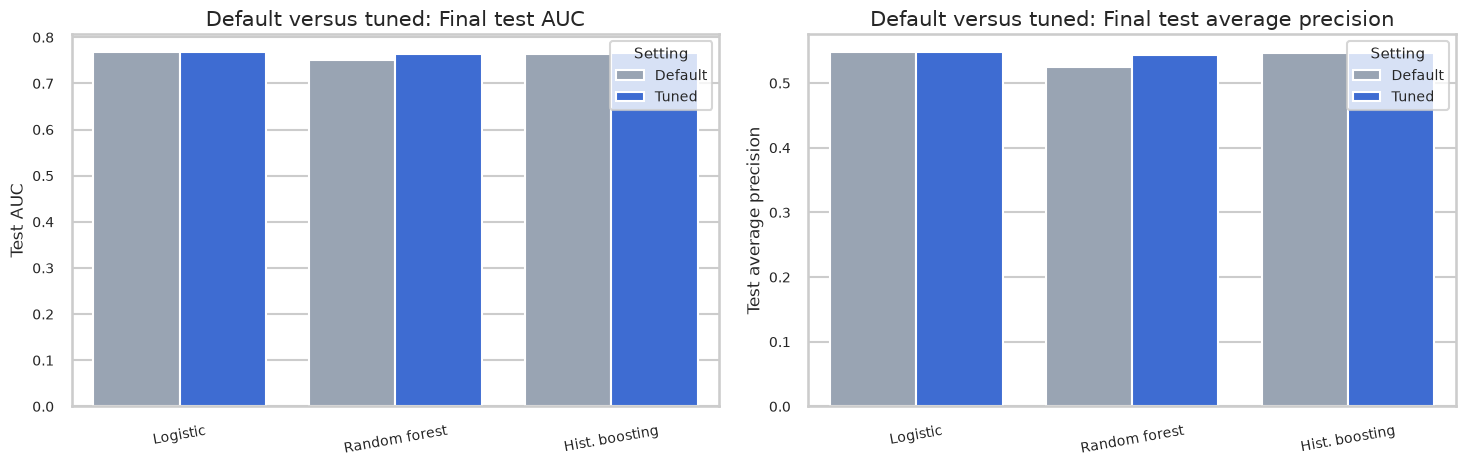

In [8]:
# Section focus: Search budgets.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

default_vs_tuned_plot = default_vs_tuned.copy()
default_vs_tuned_plot['plot_family'] = default_vs_tuned_plot['family'].replace({
    'HistGradientBoosting': 'Hist. boosting',
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=default_vs_tuned_plot, x='plot_family', y='test_auc', hue='setting', palette=['#94a3b8', '#2563eb'], ax=axes[0])
axes[0].set_title('Default versus tuned: Final test AUC')
axes[0].set_xlabel('')
axes[0].set_ylabel('Test AUC')
axes[0].tick_params(axis='x', rotation=10, labelsize=10)
legend0 = axes[0].legend(title='Setting', frameon=True, loc='upper right')
legend0.get_title().set_fontsize(11)
for text in legend0.get_texts():
    text.set_fontsize(10)

sns.barplot(data=default_vs_tuned_plot, x='plot_family', y='test_average_precision', hue='setting', palette=['#94a3b8', '#2563eb'], ax=axes[1])
axes[1].set_title('Default versus tuned: Final test average precision')
axes[1].set_xlabel('')
axes[1].set_ylabel('Test average precision')
axes[1].tick_params(axis='x', rotation=10, labelsize=10)
legend1 = axes[1].legend(title='Setting', frameon=True, loc='upper right')
legend1.get_title().set_fontsize(11)
for text in legend1.get_texts():
    text.set_fontsize(10)

plt.tight_layout()
plt.show()

The grouped comparison also makes an important operational point: search effort should be allocated where it changes decisions. If tuning a family barely moves out-of-sample performance, then the simpler default configuration may be easier to justify and maintain. If tuning materially improves a family, then the extra search cost can be worth it.

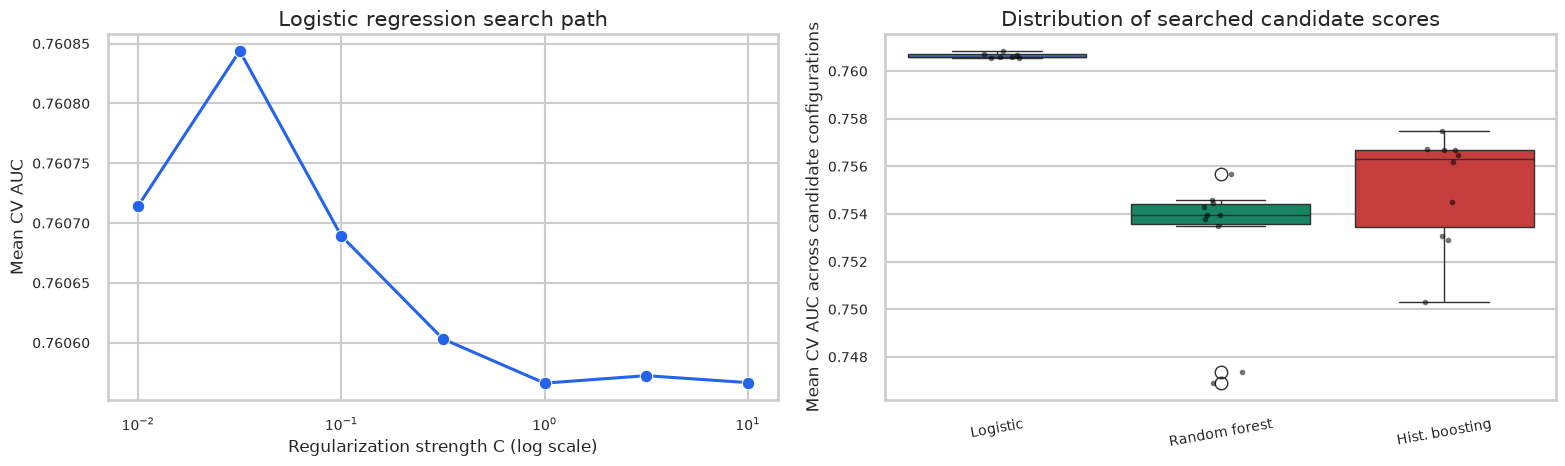

In [9]:
# Section focus: Search budgets.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

logistic_cv = pd.DataFrame(searches['Logistic regression (L2)'].cv_results_).sort_values('param_model__C').copy()
logistic_cv['param_model__C'] = logistic_cv['param_model__C'].astype(float)

candidate_scores = []
for model_name, search in searches.items():
    tmp = pd.DataFrame(search.cv_results_)
    candidate_scores.append(
        pd.DataFrame({
            'model_family': model_name.replace('Logistic regression (L2)', 'Logistic').replace('HistGradientBoosting', 'Hist. boosting'),
            'mean_cv_auc': tmp['mean_test_score'],
        })
    )

candidate_scores = pd.concat(candidate_scores, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=logistic_cv, x='param_model__C', y='mean_test_score', marker='o', linewidth=2.2, color='#2563eb', ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Logistic regression search path')
axes[0].set_xlabel('Regularization strength C (log scale)')
axes[0].set_ylabel('Mean CV AUC')

sns.boxplot(data=candidate_scores, x='model_family', y='mean_cv_auc', palette=['#2563eb', '#059669', '#dc2626'], ax=axes[1])
sns.stripplot(data=candidate_scores, x='model_family', y='mean_cv_auc', color='black', alpha=0.55, size=4, ax=axes[1])
axes[1].set_title('Distribution of searched candidate scores')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean CV AUC across candidate configurations')
axes[1].tick_params(axis='x', rotation=10, labelsize=10)

plt.tight_layout()
plt.show()

The diagnostic plots help us read the search more carefully.

- The logistic search path shows whether regularization strength changes performance sharply or only marginally.
- The candidate-score distribution shows how much room there was inside each search space. A wide distribution suggests the family is sensitive to configuration choices; a tight distribution suggests many nearby settings behave similarly.

Together, these diagnostics help us decide whether the winning configuration is a stable choice or an accident of a narrow search path.

## 5. Practical Checklist for Tuning and Comparison

When you build real operational model-selection workflows, a useful checklist is:

1. **Fix the deployment timestamp before you split anything.**
2. **Reserve the final test set before tuning starts.** Never use it to compare search strategies.
3. **Treat preprocessing as part of the model.** Imputation, scaling, and encoding belong inside the pipeline.
4. **Use a validation scheme that matches the data-generating process.** For temporal systems, that usually means forward-looking folds.
5. **Keep search budgets interpretable.** A modest, well-documented search is often better than a sprawling opaque one.
6. **Compare defaults against tuned models.** If tuning barely helps, that is a meaningful finding.
7. **Prefer the simplest model that meets the operational goal.** Deployment, monitoring, and explanation costs matter too.

A tuning workflow is successful when it produces a model choice that can survive audit and still performs well outside the notebook.

## References

- Claesen, M., Simm, J., Popović, D., et al. (2014). *Easy Hyperparameter Search Using Optunity.* [https://doi.org/10.48550/arXiv.1412.1114](https://doi.org/10.48550/arXiv.1412.1114)
- Fannjiang, C., Mooney, T. A., Cones, S., et al. (2019). *Augmenting biologging with supervised machine learning to study in situ behavior of the medusa Chrysaora fuscescens.* [https://doi.org/10.1101/657684](https://doi.org/10.1101/657684)
- Lai, M., Wulff, S. S., Cao, Y., Robinson, T. J., & Rajapaksha, R. (2025). *Temporal cross-validation in forecasting: A case study of COVID-19 incidence using wastewater data.* *Quality and Reliability Engineering International*, 41(2), 672-688. [https://doi.org/10.1002/qre.3686](https://doi.org/10.1002/qre.3686)
- Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2012). *Scikit-learn: Machine Learning in Python.* [https://doi.org/10.48550/arXiv.1201.0490](https://doi.org/10.48550/arXiv.1201.0490)
- Pfisterer, F., van Rijn, J. N., Probst, P., et al. (2018). *Learning Multiple Defaults for Machine Learning Algorithms.* [https://doi.org/10.48550/arXiv.1811.09409](https://doi.org/10.48550/arXiv.1811.09409)
